In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import gc


## Load Data

In [2]:
df = pd.read_csv("heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [3]:
print("Data Info:\n")
print(df.info())

Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


In [4]:
# Find Missing Values and Duplicates
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicate Rows: 0


In [5]:
print("Data Sample:")
print(df.head())

Data Sample:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


## EDA (Exploratory Data Analysis)

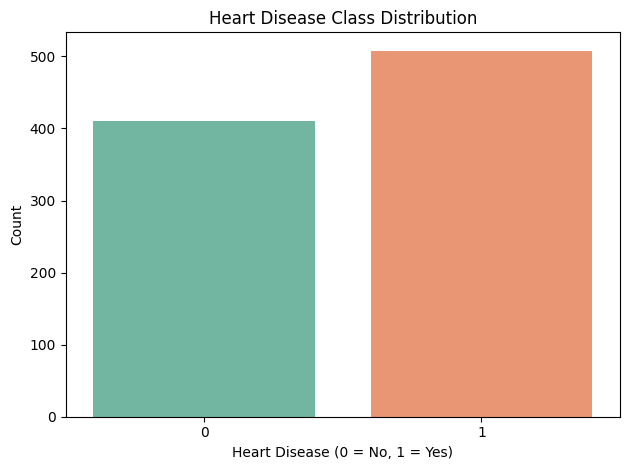

In [6]:
# Count of target classes
sns.countplot(x='HeartDisease', data=df, hue='HeartDisease', palette='Set2', legend=False)
plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

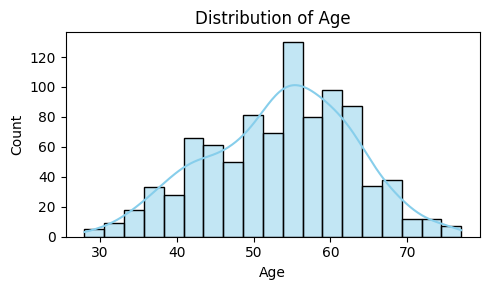

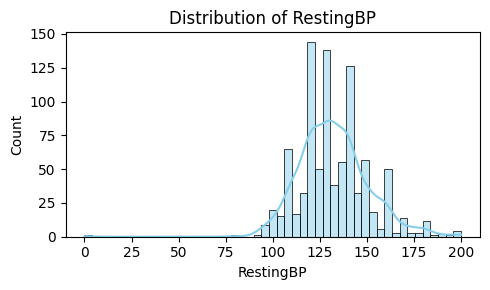

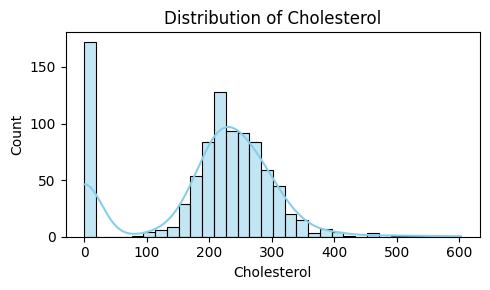

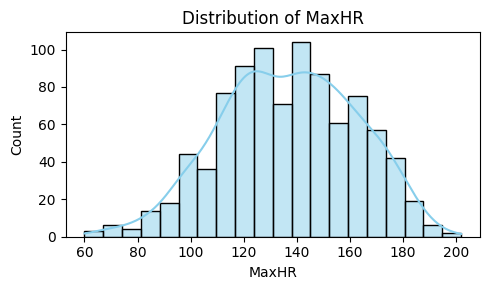

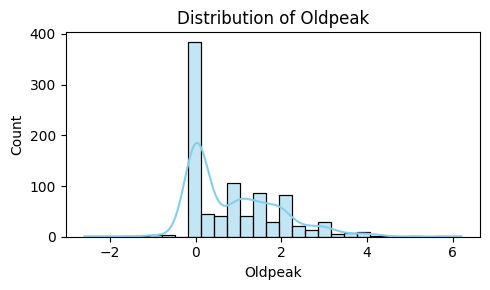

In [22]:
# Histogram of numeric columns
num_cols = ['Age','RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
for col in num_cols:
    plt.figure(figsize=(5, 3))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

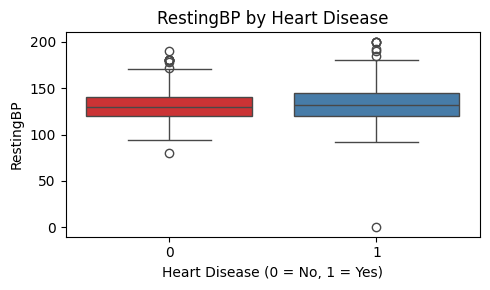

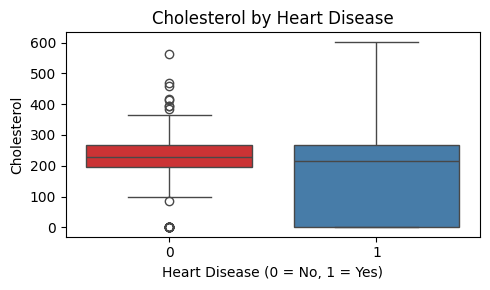

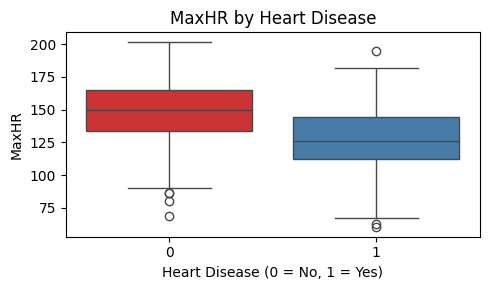

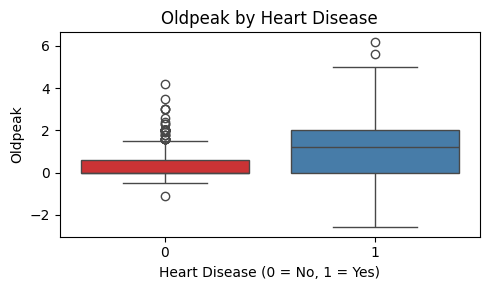

In [8]:
# Boxplot by target class
for col in num_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x='HeartDisease', y=col, data=df, hue='HeartDisease', palette='Set1', legend=False)
    plt.title(f"{col} by Heart Disease")
    plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
    plt.tight_layout()
    plt.show()


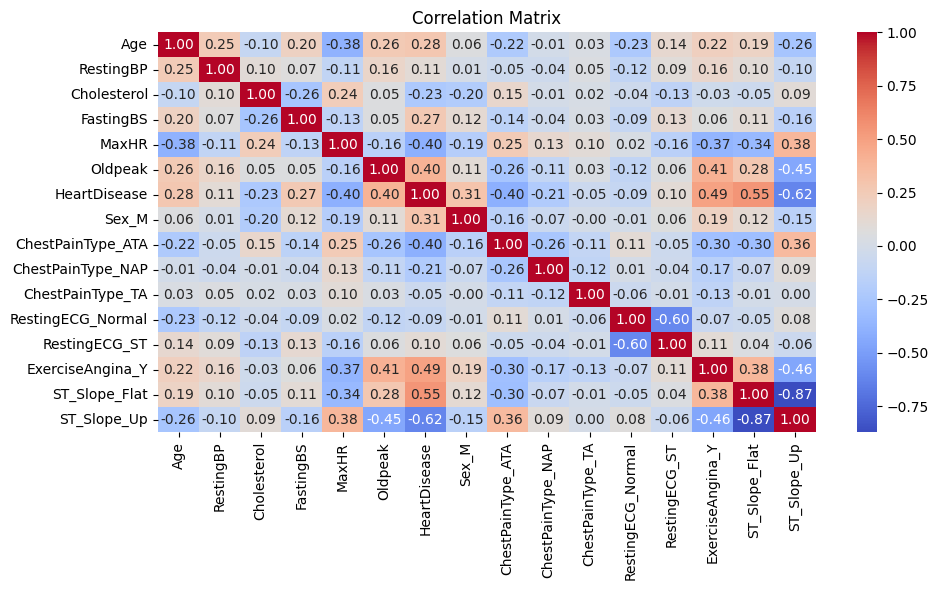

In [9]:
# Corelation Heatmap

# Convert all to numeric if needed
df = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Splitting Data

In [10]:
# define independent variables and the target variables
X = df.drop('HeartDisease', axis=1) 
y = df ['HeartDisease']

In [11]:
# split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
# Apply preprocessing to training and testing data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Support Vector Machine

In [13]:
# Initialize SVM model
svm = SVC(probability=True, random_state=42)

In [14]:
# Define the hyperparameter for grid tuning
param_grid = {
    'C': [1],                      # Regularization
    'kernel': ['linear', 'rbf', 'poly'],    # Kernel Type
    'gamma': ['scale', 0.1],                # Kernel Coefficient
    'degree': [2, 3, 4]                     # used in poly only
}

In [15]:
# Perform GridSearchCV
grid_svm = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, scoring='accuracy',n_jobs=-1)
grid_svm.fit(X_train, y_train)

,estimator,SVC(probabili...ndom_state=42)
,param_grid,"{'C': [1], 'degree': [2, 3, ...], 'gamma': ['scale', 0.1], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [16]:
# Get the best model from the GridSearch
best_svm = grid_svm.best_estimator_
print("Best Hyperparameters:", grid_svm.best_params_)

Best Hyperparameters: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}


In [17]:
# Prediction
y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

In [18]:
# Evaluation
print("Best SVM Parameters:", grid_svm.best_params_)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("AUC Score:", roc_auc_score(y_test, y_prob_svm))

Best SVM Parameters: {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
SVM Accuracy: 0.9021739130434783

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.84      0.88        82
           1       0.88      0.95      0.92       102

    accuracy                           0.90       184
   macro avg       0.91      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184


Confusion Matrix:
 [[69 13]
 [ 5 97]]
AUC Score: 0.944285031085605


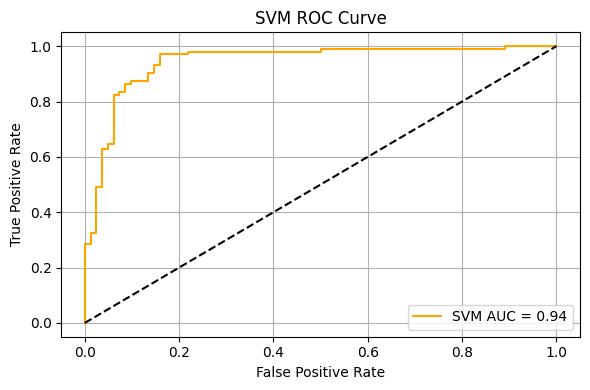

In [19]:
# ROC Curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
plt.figure(figsize=(6, 4))
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC = {roc_auc_score(y_test, y_prob_svm):.2f}", color="orange")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("SVM ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
# Save predictions and probabilities
svm_results = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_svm,
    'probability': y_prob_svm
})

# Define ErrorType column
def tag_error(row):
    if row['actual'] == 1 and row['predicted'] == 1:
        return 'True Positive'
    elif row['actual'] == 0 and row['predicted'] == 0:
        return 'True Negative'
    elif row['actual'] == 0 and row['predicted'] == 1:
        return 'False Positive'
    elif row['actual'] == 1 and row['predicted'] == 0:
        return 'False Negative'

# Calculate Confidence
svm_results['ErrorType'] = svm_results.apply(tag_error, axis=1)
svm_results['confidence'] = abs(svm_results['probability'] - 0.5)

svm_results.to_csv("svm_results5.csv", index=False)
